# Three-Model Comparison — CatBoost vs LightGBM vs XGBoost

Visualized comparison. Numbers are generated by `scripts/03_compare.py`, and predictions are cached by `scripts/02_train.py`.

The three models use the same set of partitions/features/preprocessing, so they are comparable. Run 02 and 03 first, then run this notebook.

## 0. Import + Load Predictions from Various Model Caches

In [ ]:
%matplotlib inline
import sys
from pathlib import Path
HERE = Path.cwd()
SCRIPTS = HERE / "scripts" if (HERE / "scripts").exists() else HERE.parent / "scripts"
sys.path.append(str(SCRIPTS))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sba_common import load_predictions, preds_path, MODEL_NAMES, REPORTS_DIR

MODELS = {}
for name in MODEL_NAMES:
    if preds_path(name).exists():
        p = load_predictions(name)
        MODELS[name] = (p["y_true"].to_numpy(), p["proba"].to_numpy())
    else:
        print(f"Lack of predictions for {name}, skipping (please run python scripts/02_train.py --model {name} first)")

y_true = next(iter(MODELS.values()))[0]   # The test set is the same for all models.
print("loaded:", list(MODELS), "| test default rate:", round(y_true.mean(), 4))

pd.read_csv(REPORTS_DIR / "comparison_metrics.csv")

loaded: ['catboost', 'lightgbm', 'xgboost'] | test default rate: 0.3243


,model,roc_auc,pr_auc,brier
0,catboost,0.9544,0.9042,0.0784
1,lightgbm,0.9507,0.9020,0.0821
2,xgboost,0.9506,0.8995,0.0807


## 1. Histogram of Indicators (ROC-AUC / PR-AUC)

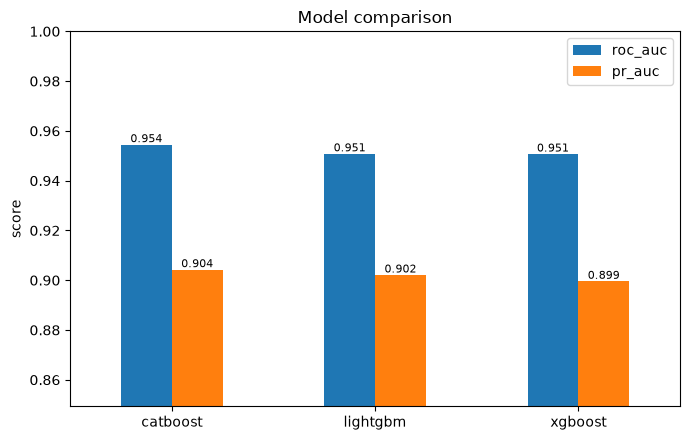

In [2]:
from sklearn.metrics import roc_auc_score, average_precision_score
m = pd.DataFrame({
    n: {"roc_auc": roc_auc_score(y, p), "pr_auc": average_precision_score(y, p)}
    for n, (y, p) in MODELS.items()
}).T
ax = m.plot(kind="bar", figsize=(7, 4.5))
ax.set_ylabel("score"); ax.set_title("Model comparison")
ax.set_ylim(max(0.0, m.values.min() - 0.05), 1.0)
plt.xticks(rotation=0)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.3f", fontsize=8)
plt.tight_layout(); plt.show()

## 2. ROC Curve Overlay

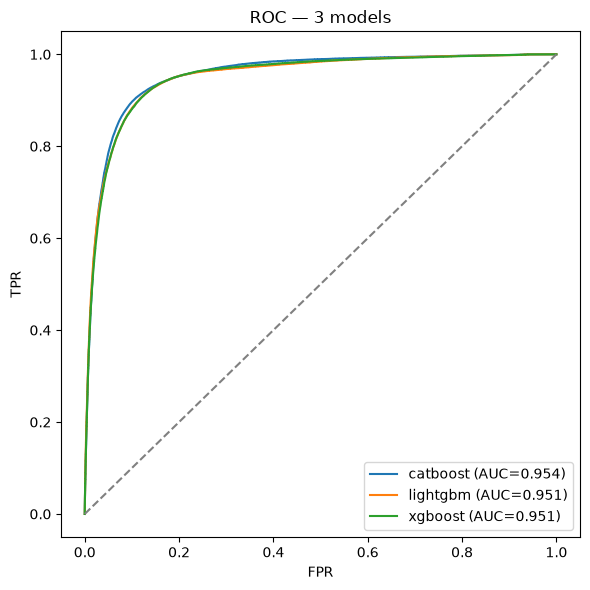

In [3]:
from sklearn.metrics import roc_curve
plt.figure(figsize=(6, 6))
for n, (y, p) in MODELS.items():
    fpr, tpr, _ = roc_curve(y, p)
    plt.plot(fpr, tpr, label=f"{n} (AUC={roc_auc_score(y, p):.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC — 3 models"); plt.legend()
plt.tight_layout(); plt.show()

## 3. Overlaying PR curves (more critical under unbalanced conditions)

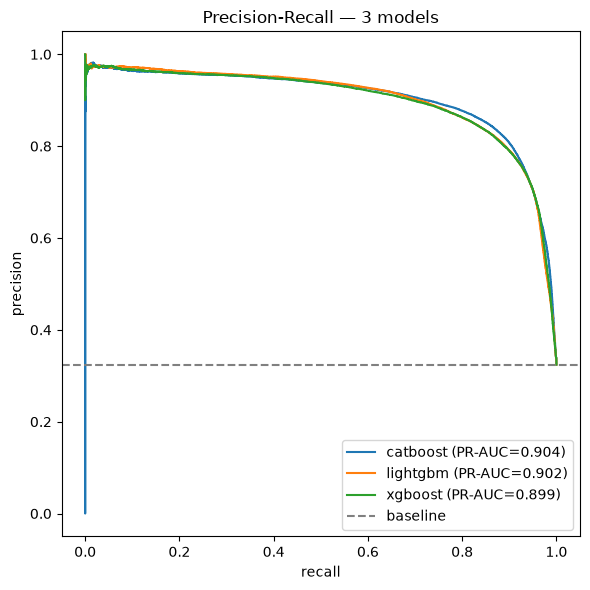

In [4]:
from sklearn.metrics import precision_recall_curve
plt.figure(figsize=(6, 6))
for n, (y, p) in MODELS.items():
    prec, rec, _ = precision_recall_curve(y, p)
    plt.plot(rec, prec, label=f"{n} (PR-AUC={average_precision_score(y, p):.3f})")
plt.axhline(y_true.mean(), ls="--", color="grey", label="baseline")
plt.xlabel("recall"); plt.ylabel("precision"); plt.title("Precision-Recall — 3 models"); plt.legend()
plt.tight_layout(); plt.show()

## 4. Probability Calibration and Overlay (admin - Decision by Probability -> Accurate Probability)

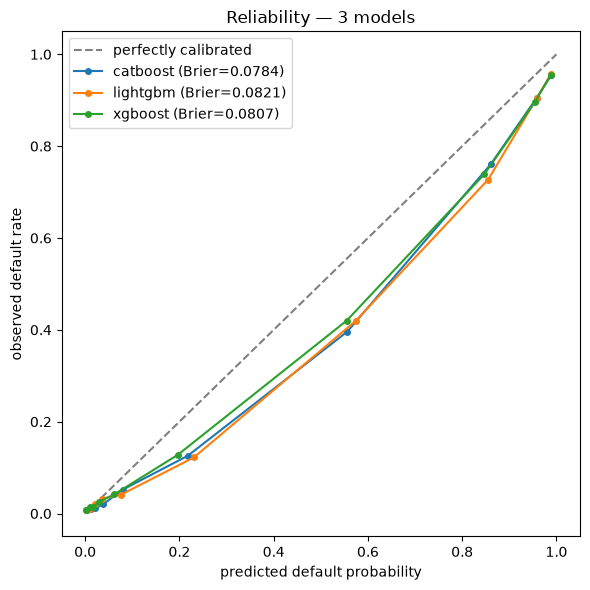

In [5]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "--", color="grey", label="perfectly calibrated")
for n, (y, p) in MODELS.items():
    pt, pp = calibration_curve(y, p, n_bins=10, strategy="quantile")
    plt.plot(pp, pt, "o-", ms=4, label=f"{n} (Brier={brier_score_loss(y, p):.4f})")
plt.xlabel("predicted default probability"); plt.ylabel("observed default rate")
plt.title("Reliability — 3 models"); plt.legend()
plt.tight_layout(); plt.show()

## 5. Selection Conclusion (For Report Writing)

Don't just choose the one with the highest ROC-AUC. Suggested order: **PR-AUC** (more realistic in minority classes) > **Brier/Calibration** (decision based on probability)

> Stability/Speed/Interpretability. Explaining "why it was chosen" in the report is more convincing than simply reporting the highest score.

After deciding: `python scripts/04_decision.py --model <winner>`, then look at `04_decision.ipynb`.